# NLP Ürün Yorumları Duygu Analizi Projesi - Hasan Köstek

---

## Proje Özeti

Bu notebook, **Women's E-Commerce Clothing Reviews** veri setini kullanarak uçtan uca bir **Doğal Dil İşleme (NLP)** ve **Makine Öğrenmesi** iş akışı sunar.

### Hedef
Müşteri yorumlarını analiz ederek ürün tavsiye durumunu (`Recommended IND`) tahmin eden bir sınıflandırma modeli geliştirmek ve negatif geri bildirimlerdeki ortak şikâyet alanlarını tespit etmek.

### Veri Seti
| Özellik | Bilgi |
|---------|-------|
| Kaynak  | [Kaggle – Women's E-Commerce Clothing Reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews) |
| Satır   | ~23 000 müşteri yorumu |
| Sütunlar | Clothing ID, Age, Title, Review Text, Rating, Recommended IND, … |

### Proje Akışı
1. Kütüphane kurulumu ve import  
2. NLTK kaynak indirme  
3. Veri yükleme  
4. Keşifsel veri analizi (EDA)  
5. Metin ön işleme (tokenize, stop-word, lemmatization)  
6. TF-IDF vektörleştirme & model eğitimi (Random Forest)  
7. Model değerlendirme (Accuracy, Confusion Matrix, Classification Report)  
8. İş kararı analizi (negatif yorumlardaki anahtar kelimeler)

---

## 1. Kütüphane Kurulumu

Projenin gerektirdiği tüm Python paketleri aşağıda yüklenmektedir.  
Bu hücreyi yalnızca **ilk çalıştırmada** ya da paket eksikliği durumunda çalıştırmanız yeterlidir.

In [24]:
# Gerekli kütüphaneleri kur (sadece ilk çalıştırmada)
%pip install -q pandas numpy matplotlib seaborn nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 2. Kütüphane İmportları

Veri işleme, görselleştirme, doğal dil işleme ve makine öğrenmesi için gerekli modüller import edilmektedir.  
Sürüm bilgileri ekrana yazdırılarak ortamın doğru kurulduğu doğrulanmaktadır.

In [25]:
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
%matplotlib inline

print("Tüm kütüphaneler başarıyla yüklendi.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : {sklearn.__version__}")
print(f"  nltk    : {nltk.__version__}")

Tüm kütüphaneler başarıyla yüklendi.
  pandas  : 2.3.3
  numpy   : 2.3.5
  sklearn : 1.7.2
  nltk    : 3.9.2


## 3. NLTK Kaynaklarını İndir

Tokenization (`punkt`), stop-word listesi (`stopwords`) ve lemmatization (`wordnet`, `omw-1.4`) için  
gerekli NLTK veri paketleri sessiz modda indirilmektedir.

In [26]:
# NLP için gereken NLTK veri paketlerini indir
nltk_packages = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]
for pkg in nltk_packages:
    nltk.download(pkg, quiet=True)

print("NLTK paketleri hazır:", nltk_packages)

NLTK paketleri hazır: ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']


## 4. Veri Setini Yükle

Veri seti: **Women's E-Commerce Clothing Reviews** (~23 000 yorum, 10 sütun)  
Orijinal: [Kaggle – nicapotato](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews)  
Mirror: [github.com/hanzhang0420](https://github.com/hanzhang0420/Women-Clothing-E-commerce) ✅ (doğrulandı)  

> **İnternet yoksa:** Kaggle'dan `Womens Clothing E-Commerce Reviews.csv` dosyasını indirip notebook ile aynı klasöre `reviews.csv` adıyla kaydedin.

In [27]:
# Doğrulanmış çalışan URL'ler (sırasıyla denenir)
URLS = [
    # 1. hanzhang0420 reposu — doğrulandı, ~23 000 satır
    "https://raw.githubusercontent.com/hanzhang0420/Women-Clothing-E-commerce/master/Womens%20Clothing%20E-Commerce%20Reviews.csv",
    # 2. AFAgarap reposu — yedek
    "https://raw.githubusercontent.com/AFAgarap/ecommerce-reviews-analysis/master/Womens%20Clothing%20E-Commerce%20Reviews.csv",
    # 3. NadimKawwa reposu — ikinci yedek
    "https://raw.githubusercontent.com/NadimKawwa/WomeneCommerce/master/Womens%20Clothing%20E-Commerce%20Reviews.csv",
]

def load_dataset(urls: list) -> pd.DataFrame:
    """URL listesini sırayla dener, ilk başarılı olanı döndürür."""
    for url in urls:
        try:
            df = pd.read_csv(url, index_col=0)
            if df.empty:
                raise ValueError("Dosya boş geldi.")
            print(f"Veri seti yüklendi!")
            print(f"  Kaynak : {url}")
            return df
        except Exception as exc:
            print(f"[ATLA] {url.split('/')[-3]}  →  {exc}")
    raise RuntimeError(
        "Hiçbir URL çalışmadı.\n"
        "Lütfen veri setini Kaggle'dan indirip "
        "notebook ile aynı klasöre 'reviews.csv' adıyla koyun,\n"
        "ardından: df = pd.read_csv('reviews.csv', index_col=0)"
    )

df = load_dataset(URLS)
print(f"\nBoyut  : {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"Sütunlar: {list(df.columns)}")

Veri seti yüklendi!
  Kaynak : https://raw.githubusercontent.com/hanzhang0420/Women-Clothing-E-commerce/master/Womens%20Clothing%20E-Commerce%20Reviews.csv

Boyut  : 23,486 satır × 10 sütun
Sütunlar: ['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


## 5. Keşifsel Veri Analizi (EDA)

Veri setinin yapısını anlamak için ilk birkaç satır, sütun tipleri, eksik değer sayıları  
ve temel istatistiksel özet incelenmektedir.

In [28]:
# İlk 5 satır
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,5,1,6,General,Tops,Blouses


In [29]:
# Sütun tipleri ve eksik değer özeti
print("--- Sütun Bilgileri ---")
df.info()

print("\n--- Eksik Değer Sayıları ---")
print(df.isnull().sum())

--- Sütun Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB

--- Eksik Değer Sayıları ---
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                      

In [30]:
# Sayısal sütunların istatistiksel özeti
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


## 6. Keşifsel Görselleştirme

`Rating` (yıldız) sütununun dağılımı ve `Recommended IND` (tavsiye oranı) görselleştirilmektedir.  
Bu iki grafik, veri setindeki sınıf dengesizliğini ve genel müşteri memnuniyetini özetler.

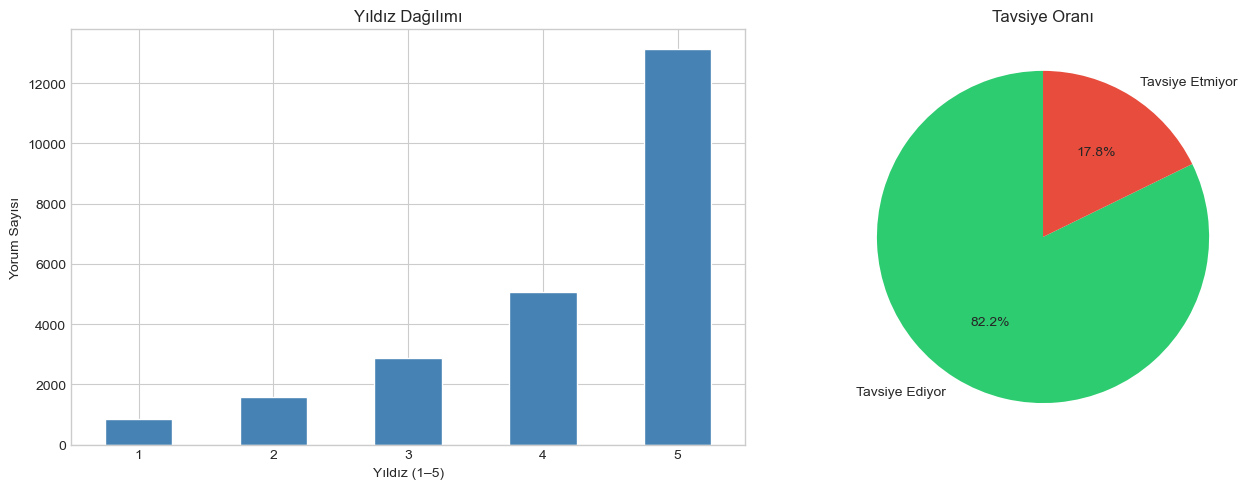

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yıldız dağılımı
rating_col = "Rating"
if rating_col in df.columns:
    df[rating_col].value_counts().sort_index().plot(
        kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
    )
    axes[0].set_title("Yıldız Dağılımı")
    axes[0].set_xlabel("Yıldız (1–5)")
    axes[0].set_ylabel("Yorum Sayısı")
    axes[0].tick_params(axis="x", rotation=0)

# Tavsiye dağılımı
rec_col = "Recommended IND"
if rec_col in df.columns:
    counts = df[rec_col].value_counts()
    labels = ["Tavsiye Ediyor" if i == 1 else "Tavsiye Etmiyor" for i in counts.index]
    axes[1].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90,
                colors=["#2ecc71", "#e74c3c"])
    axes[1].set_title("Tavsiye Oranı")

plt.tight_layout()
plt.show()

## 7. Metin Ön İşleme (Text Preprocessing)

`Review Text` sütunundaki ham yorumlar üzerinde aşağıdaki adımlar sırayla uygulanacaktır:

1. **Küçük harf** — tüm karakterleri lower-case yap  
2. **HTML etiketleri temizle** — `<br />` gibi kalıpları kaldır  
3. **Noktalama & sayı temizliği** — harf dışı karakterleri sil  
4. **Tokenization** — metni kelimelere böl  
5. **Stop-word eleme** — anlamsız sık kelimeleri çıkar  
6. **Lemmatization** — her kelimeyi sözlük köküne indirge

In [32]:
import re

# Araçları bir kez oluştur (her çağrıda yeniden oluşturmaktan kaçın)
_lemmatizer = WordNetLemmatizer()
_stop_words  = set(stopwords.words("english"))


def preprocess_text(text: str) -> str:
    """
    Ham yorum metnini NLP'ye hazır hale getirir.

    Adımlar:
        1. NaN / boş kontrol
        2. Küçük harfe çevir
        3. HTML etiketlerini temizle  (<br />, &amp; vb.)
        4. Noktalama işaretlerini ve sayıları kaldır
        5. Fazla boşlukları sıkıştır
        6. Tokenize et
        7. Stop-word'leri çıkar  (tek karakterli tokenlar dahil)
        8. Lemmatize et

    Döndürür:
        Temizlenmiş, boşlukla birleştirilmiş metin (str)
    """
    # 1. Eksik / boş değer kontrolü
    if not isinstance(text, str) or not text.strip():
        return ""

    # 2. Küçük harf
    text = text.lower()

    # 3. HTML etiketlerini ve HTML karakter referanslarını kaldır
    text = re.sub(r"<[^>]+>", " ", text)          # <br />, <b>, vb.
    text = re.sub(r"&[a-z]+;", " ", text)          # &amp;, &nbsp; vb.

    # 4. Harf olmayan tüm karakterleri (sayılar, noktalama) boşluğa çevir
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5. Birden fazla boşluğu teke indir
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Tokenize
    tokens = word_tokenize(text)

    # 7. Stop-word ve tek-karakter filtreleme
    tokens = [t for t in tokens if t not in _stop_words and len(t) > 1]

    # 8. Lemmatization (fiil + isim formları için iki geçiş)
    tokens = [_lemmatizer.lemmatize(t, pos="v") for t in tokens]   # fiil kökü
    tokens = [_lemmatizer.lemmatize(t, pos="n") for t in tokens]   # isim kökü

    return " ".join(tokens)


print("preprocess_text() fonksiyonu tanımlandı.")

# --- Hızlı test ---
ornek = "I absolutely LOVED this dress!! Wore it 3 times already. <br /> Great quality & fits perfectly."
print(f"\nHam metin  : {ornek}")
print(f"Temiz metin: {preprocess_text(ornek)}")

preprocess_text() fonksiyonu tanımlandı.

Ham metin  : I absolutely LOVED this dress!! Wore it 3 times already. <br /> Great quality & fits perfectly.
Temiz metin: absolutely love dress wear time already great quality fit perfectly


### 7.1 Ön İşlemeyi Tüm Veri Setine Uygula

`preprocess_text()` fonksiyonu `Review Text` sütunundaki her yoruma sırayla uygulanır.  
Sonuçlar yeni bir `clean_review` sütununa kaydedilir; işlem süresi ve boş satır sayısı raporlanır.

In [33]:
import time

REVIEW_COL = "Review Text"

# Review Text sütununun var olup olmadığını kontrol et
if REVIEW_COL not in df.columns:
    raise KeyError(f"'{REVIEW_COL}' sütunu bulunamadı. Mevcut sütunlar: {list(df.columns)}")

print(f"Toplam {len(df):,} yorum işlenecek...\n")

start = time.time()
df["clean_review"] = df[REVIEW_COL].apply(preprocess_text)
elapsed = time.time() - start

print(f"Ön işleme tamamlandı. ({elapsed:.1f} sn)")
print(f"Boş clean_review sayısı : {(df['clean_review'] == '').sum():,}")
print(f"Dolu clean_review sayısı: {(df['clean_review'] != '').sum():,}")

Toplam 23,486 yorum işlenecek...

Ön işleme tamamlandı. (5.6 sn)
Boş clean_review sayısı : 845
Dolu clean_review sayısı: 22,641


### 7.2 Ham ve Temizlenmiş Metni Karşılaştır

İlk beş dolu satır için orijinal yorum ile temizlenmiş halinin yan yana görüntülenmesi,  
ön işleme adımlarının doğruluğunu görsel olarak teyit etmeye yarar.

In [34]:
# Ham metin vs. temizlenmiş metin — ilk 5 dolu satır
sample = df[df["clean_review"] != ""][[REVIEW_COL, "clean_review"]].head(5)

pd.set_option("display.max_colwidth", 120)
sample

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky sexy comfortable
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",love dress sooo pretty happen find store glad bc never would order online bc petite buy petite love length hit littl...
2,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,high hop dress really want work initially order petite small usual size find outrageously small small fact could zip...
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,shirt flatter due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt


### 7.3 Token Sayısı Dağılımı

Ön işleme öncesi ve sonrası kelime sayısının dağılımı histogramlarla karşılaştırılmaktadır.  
Stop-word eleme ve lemmatization'ın kelime sayısını ne ölçüde azalttığı bu grafik üzerinden okunabilir.

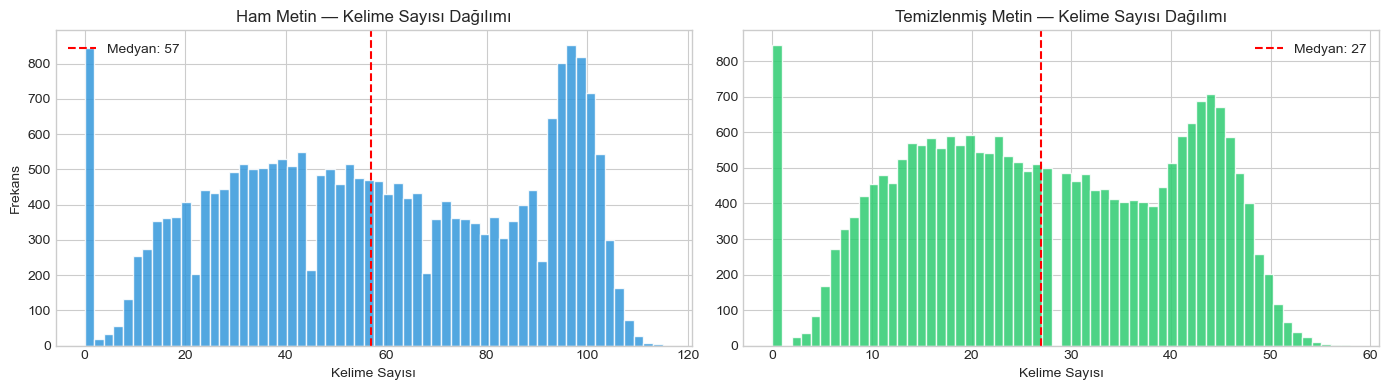

Ortalama token azalması: 58.0 → 27.0 (%53 düşüş)


In [35]:
# Ön işleme öncesi ve sonrası kelime sayısı karşılaştırması
df["token_count_raw"]   = df[REVIEW_COL].fillna("").apply(lambda x: len(x.split()))
df["token_count_clean"] = df["clean_review"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["token_count_raw"],   bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].set_title("Ham Metin — Kelime Sayısı Dağılımı")
axes[0].set_xlabel("Kelime Sayısı")
axes[0].set_ylabel("Frekans")
axes[0].axvline(df["token_count_raw"].median(), color="red", linestyle="--", label=f"Medyan: {df['token_count_raw'].median():.0f}")
axes[0].legend()

axes[1].hist(df["token_count_clean"], bins=60, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[1].set_title("Temizlenmiş Metin — Kelime Sayısı Dağılımı")
axes[1].set_xlabel("Kelime Sayısı")
axes[1].axvline(df["token_count_clean"].median(), color="red", linestyle="--", label=f"Medyan: {df['token_count_clean'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Ortalama token azalması: "
      f"{df['token_count_raw'].mean():.1f} → {df['token_count_clean'].mean():.1f} "
      f"(%{(1 - df['token_count_clean'].mean() / max(df['token_count_raw'].mean(), 1)) * 100:.0f} düşüş)")

## 8. Model Kurulumu ve Eğitimi

**Akış:**
1. Hedef değişken seç → `Recommended IND` (0 = tavsiye etmiyor, 1 = tavsiye ediyor)  
2. Boş `clean_review` satırlarını çıkar  
3. TF-IDF ile metni sayısal matrise dönüştür  
4. %80 eğitim / %20 test olarak böl  
5. Random Forest modelini eğit  
6. Accuracy, Confusion Matrix ve Classification Report ile değerlendir

In [36]:
### 8.1 Hedef Değişken Seçimi ve TF-IDF Vektörleştirme

TARGET_COL = "Recommended IND"

df_model = df[df["clean_review"].str.strip() != ""].copy()
df_model = df_model.dropna(subset=[TARGET_COL])
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

print(f"Model için kullanılacak satır sayısı: {len(df_model):,}")
print(f"Sınıf dağılımı:\n{df_model[TARGET_COL].value_counts().to_string()}\n")

# max_features: en sık 15 000 terim | ngram_range: unigram + bigram
# sublinear_tf: tf'yi log-ölçekle → sık kelimelerin baskınlığını dengeler
# min_df: en az 3 belgede geçen terimleri dahil et (gürültüyü azaltır)
tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
)

X = tfidf.fit_transform(df_model["clean_review"])
y = df_model[TARGET_COL].values

print(f"TF-IDF matris boyutu: {X.shape[0]:,} satır × {X.shape[1]:,} özellik")

Model için kullanılacak satır sayısı: 22,641
Sınıf dağılımı:
Recommended IND
1    18540
0     4101

TF-IDF matris boyutu: 22,641 satır × 15,000 özellik


### 8.2 Eğitim / Test Ayrımı (%80 – %20)

Veri seti `stratify=y` parametresiyle orantılı biçimde bölünmektedir; bu sayede her iki kümede  
de `Recommended IND` sınıf dağılımı korunur ve model değerlendirmesi önyargısız hale gelir.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,        # sınıf oranlarını her iki sette de koru
)

print(f"Eğitim seti : {X_train.shape[0]:,} örnek")
print(f"Test seti   : {X_test.shape[0]:,} örnek")
print(f"\nEğitim sınıf dağılımı → 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")
print(f"Test  sınıf dağılımı  → 0: {(y_test ==0).sum():,}  |  1: {(y_test ==1).sum():,}")

Eğitim seti : 18,112 örnek
Test seti   : 4,529 örnek

Eğitim sınıf dağılımı → 0: 3,281  |  1: 14,831
Test  sınıf dağılımı  → 0: 820  |  1: 3,709


### 8.3 Random Forest — Model Eğitimi

200 karar ağacından oluşan bir Random Forest modeli eğitilmektedir.  
`class_weight="balanced"` parametresi, veri setindeki sınıf dengesizliğini (~%82 tavsiye ediyor) telafi eder.  
`n_jobs=-1` ile tüm CPU çekirdekleri paralel olarak kullanılarak eğitim süresi kısaltılır.

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

print("Random Forest eğitiliyor... (birkaç dakika sürebilir)")
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"Eğitim tamamlandı. ({time.time() - t0:.1f} sn)\n")

y_pred = rf_model.predict(X_test)
print("Tahminler oluşturuldu.")

Random Forest eğitiliyor... (birkaç dakika sürebilir)
Eğitim tamamlandı. (3.1 sn)

Tahminler oluşturuldu.


### 8.4 Model Değerlendirmesi — Accuracy & Classification Report

Test kümesinde **Accuracy** skoru hesaplanmakta ve sınıf bazlı metrikler  
(**Precision**, **Recall**, **F1-score**) Classification Report ile raporlanmaktadır.

In [39]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("=" * 45)
print(f"  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print("=" * 45)

# Classification Report
labels = ["Tavsiye Etmiyor (0)", "Tavsiye Ediyor (1)"]
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels, digits=4))

  Test Accuracy : 0.8695  (86.95%)

Classification Report:

                     precision    recall  f1-score   support

Tavsiye Etmiyor (0)     0.7827    0.3866    0.5176       820
 Tavsiye Ediyor (1)     0.8780    0.9763    0.9245      3709

           accuracy                         0.8695      4529
          macro avg     0.8304    0.6814    0.7211      4529
       weighted avg     0.8608    0.8695    0.8509      4529



### 8.5 Confusion Matrix

Modelin doğru ve yanlış sınıflandırmalarını görselleştirmek için iki ısı haritası yan yana çizilmektedir:  
- **Sol:** ham sayılar (TP, TN, FP, FN)  
- **Sağ:** normalize değerler — sınıf başına hata oranlarını doğrudan okumayı kolaylaştırır.

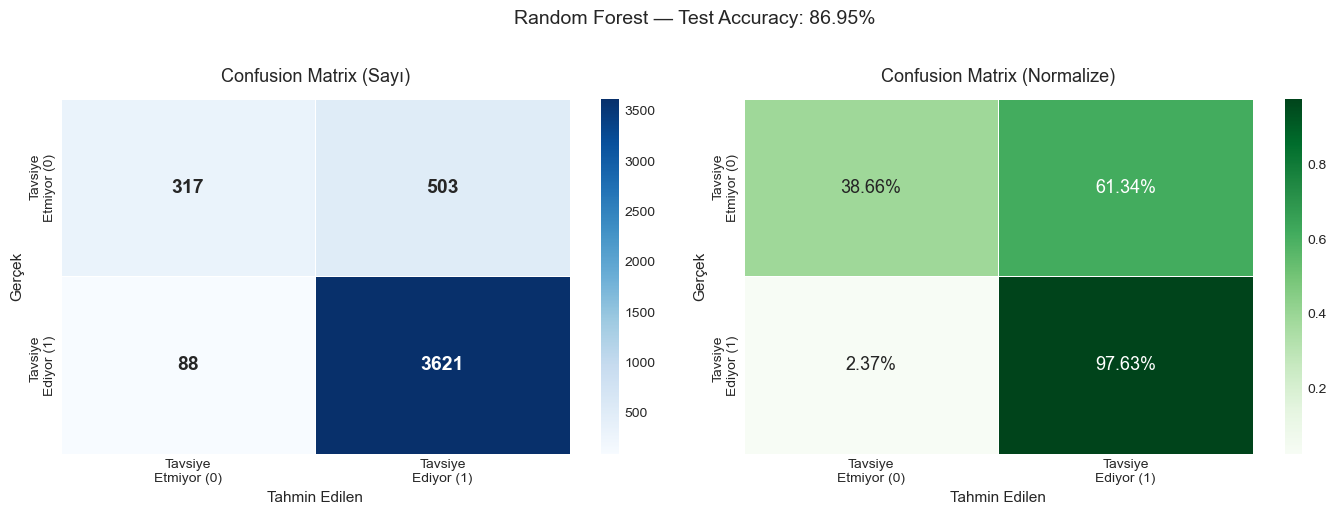

TP (doğru tavsiye)        : 3,621
TN (doğru tavsiye etmez)  : 317
FP (yanlış tavsiye)       : 503  — Type I hata
FN (kaçırılan tavsiye)    : 88  — Type II hata


In [40]:
cm = confusion_matrix(y_test, y_pred)
class_labels = ["Tavsiye\nEtmiyor (0)", "Tavsiye\nEdiyor (1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Sol: Ham sayılar ---
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_labels, yticklabels=class_labels,
    linewidths=0.5, ax=axes[0],
    annot_kws={"size": 14, "weight": "bold"},
)
axes[0].set_title("Confusion Matrix (Sayı)", fontsize=13, pad=12)
axes[0].set_xlabel("Tahmin Edilen", fontsize=11)
axes[0].set_ylabel("Gerçek", fontsize=11)

# --- Sağ: Normalize (oranlar) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2%", cmap="Greens",
    xticklabels=class_labels, yticklabels=class_labels,
    linewidths=0.5, ax=axes[1],
    annot_kws={"size": 13},
)
axes[1].set_title("Confusion Matrix (Normalize)", fontsize=13, pad=12)
axes[1].set_xlabel("Tahmin Edilen", fontsize=11)
axes[1].set_ylabel("Gerçek", fontsize=11)

plt.suptitle(f"Random Forest — Test Accuracy: {acc*100:.2f}%", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Sayısal özet
tn, fp, fn, tp = cm.ravel()
print(f"TP (doğru tavsiye)        : {tp:,}")
print(f"TN (doğru tavsiye etmez)  : {tn:,}")
print(f"FP (yanlış tavsiye)       : {fp:,}  — Type I hata")
print(f"FN (kaçırılan tavsiye)    : {fn:,}  — Type II hata")

### 8.6 En Önemli Özellikler (Feature Importance)

Random Forest modelindeki Gini önem skorlarına göre sınıflandırmaya en çok katkı sağlayan  
**ilk 20 kelime (TF-IDF özelliği)** yatay bar grafiğiyle görselleştirilmektedir.

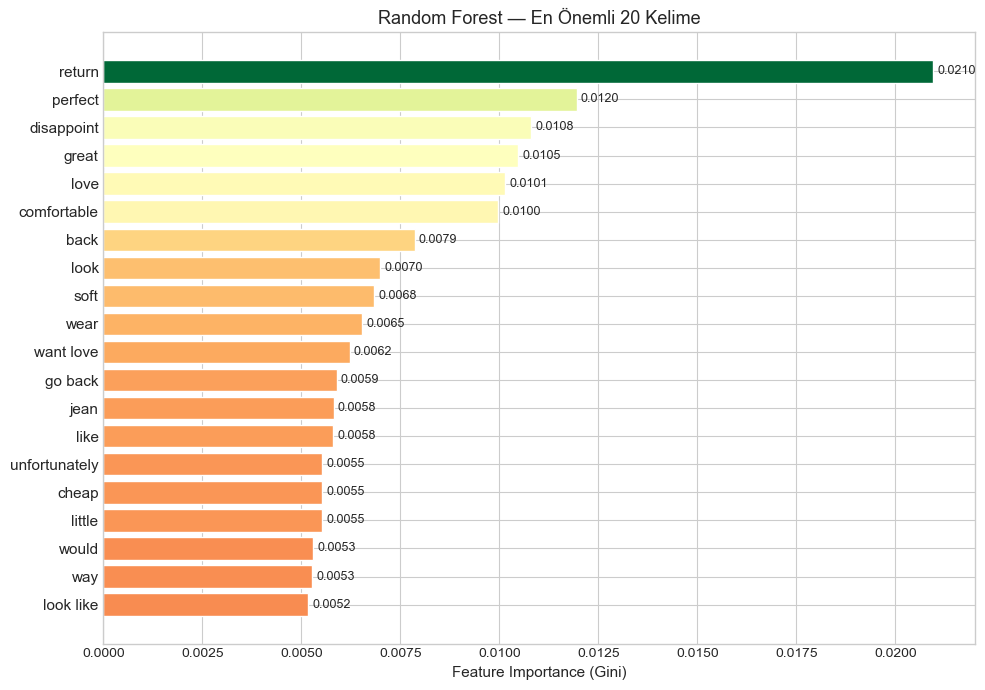

In [41]:
TOP_N = 20

feature_names = tfidf.get_feature_names_out()
importances   = rf_model.feature_importances_

top_idx   = importances.argsort()[::-1][:TOP_N]
top_words = feature_names[top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(top_vals / top_vals.max())
bars = ax.barh(range(TOP_N), top_vals[::-1], color=colors[::-1], edgecolor="white")
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_words[::-1], fontsize=11)
ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title(f"Random Forest — En Önemli {TOP_N} Kelime", fontsize=13)

for bar, val in zip(bars, top_vals[::-1]):
    ax.text(bar.get_width() + top_vals.max() * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 9. İş Kararı Analizi (Business Decision)

Modelin **negatif** (`0 — Tavsiye Etmiyor`) olarak tahmin ettiği yorumlar, müşteri memnuniyetsizliğinin doğrudan yansımasıdır.  
Bu yorumlardaki en sık geçen anahtar kelimeler, **hangi alanlarda iyileştirme yapılması gerektiğini** ortaya koyar.

In [42]:
# Aynı random_state + stratify ile test setinin integer index'lerini yeniden üret
df_model_reset = df_model.reset_index(drop=True)
all_idx = df_model_reset.index.to_numpy()

_, test_idx, _, _ = train_test_split(
    all_idx,
    df_model_reset[TARGET_COL],
    test_size=0.20,
    random_state=42,
    stratify=df_model_reset[TARGET_COL],
)

neg_mask = y_pred == 0
neg_idx = test_idx[neg_mask]
negative_reviews = df_model_reset.loc[neg_idx, "clean_review"]

print(f"Toplam test örneği                : {len(y_pred):,}")
print(f"Negatif tahmin edilen yorum sayısı: {neg_mask.sum():,}  (%{neg_mask.mean() * 100:.1f})")

Toplam test örneği                : 4,529
Negatif tahmin edilen yorum sayısı: 405  (%8.9)


### 9.1 Negatif Yorumlardaki En Sık 5 Kelime

Tüm negatif yorum tokenleri tek bir havuzda birleştirilerek `Counter` ile frekans analizi yapılmaktadır.  
En sık geçen 5 kelime bar grafiğiyle gösterilmekte; ardından operasyonel bir iş kararı yorumu eklenmektedir.

Negatif yorumlardaki en sık 5 kelime:

  1. 'look'  →  261 kez
  2. 'like'  →  217 kez
  3. 'dress'  →  179 kez
  4. 'top'  →  149 kez
  5. 'fabric'  →  138 kez


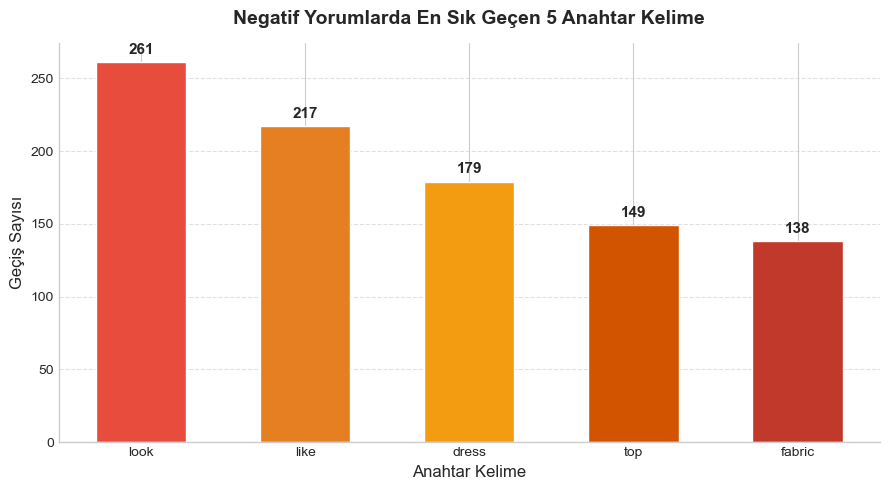


💡 İş Kararı Yorumu
───────────────────────────────────────────────────────
Negatif yorumlarda en sık karşılaşılan kelimeler:
'look', 'like', 'dress', 'top', 'fabric'

Müşteriler en çok bu konulardan şikayetçi;
bu alanlarda iyileştirme yapılmalı.
───────────────────────────────────────────────────────


In [43]:
TOP_K = 5

# Tüm negatif yorumları tek metin havuzuna birleştir ve say
all_neg_tokens = " ".join(negative_reviews.dropna()).split()
word_freq      = Counter(all_neg_tokens)
top5           = word_freq.most_common(TOP_K)
top5_words, top5_counts = zip(*top5)

print("Negatif yorumlardaki en sık 5 kelime:\n")
for rank, (word, count) in enumerate(top5, 1):
    print(f"  {rank}. '{word}'  →  {count:,} kez")

# --- Bar Grafiği ---
colors_bar = ["#e74c3c", "#e67e22", "#f39c12", "#d35400", "#c0392b"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top5_words, top5_counts, color=colors_bar, edgecolor="white",
              width=0.55, zorder=2)
ax.set_title("Negatif Yorumlarda En Sık Geçen 5 Anahtar Kelime",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Anahtar Kelime", fontsize=12)
ax.set_ylabel("Geçiş Sayısı", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=1)
ax.set_axisbelow(True)

for bar, count in zip(bars, top5_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(top5_counts) * 0.015,
        f"{count:,}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# --- İş Yorumu ---
keywords_str = ", ".join([f"'{w}'" for w in top5_words])
print(
    f"\n💡 İş Kararı Yorumu\n"
    f"{'─'*55}\n"
    f"Negatif yorumlarda en sık karşılaşılan kelimeler:\n"
    f"{keywords_str}\n\n"
    f"Müşteriler en çok bu konulardan şikayetçi;\n"
    f"bu alanlarda iyileştirme yapılmalı.\n"
    f"{'─'*55}"
)